# Exercises

---

In [2]:
import numpy as np
from scipy import io
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pylab as plt
import seaborn as sns
import sys
import os
sys.path.append(os.path.abspath("code"))
from utils import download_data

sns.set_theme(context='notebook',style='white',font_scale=1.5,
              rc = {'axes.spines.top':False,'axes.spines.right':False})

## Exercise 1: structured and ustructured images
Write a function that outputs the number of PC you have to choose to retain a given percentage of explained variance.
Use this funtion on the  handwritten digit data, and plot the number of PC needed to retain a certain fraction of EVR, for a few vaules of EVR.

Compare this curve to the one you can obtain in unstructured images: either generate images with the same shape of our data or randomly permute the pixels in each image independenlty. How does the number of PC needed to retain a certain fraction of the variance in this case compare to the number needed for digit images?

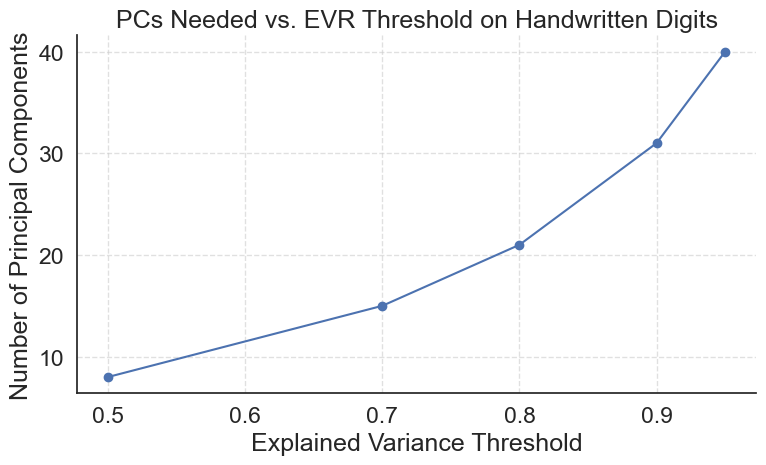

In [13]:
def get_N_pc(images, percentage):
    # defines a scaler objects
    scaler = StandardScaler()
    # z-score with fit_transform method
    X =scaler.fit_transform(images)

    pca = PCA()
    pca.fit(X)

    cum_var = np.cumsum(pca.explained_variance_ratio_)
    return np.argmax(cum_var >= percentage) + 1

# load image data
dataset = load_digits()
images = dataset.data
thresholds = [0.5, 0.7, 0.8, 0.9, 0.95]
pcs_needed = [get_N_pc(images, th) for th in thresholds]

plt.figure(figsize=(8, 5))
plt.plot(thresholds, pcs_needed, marker='o', linestyle='-')
plt.xlabel('Explained Variance Threshold')
plt.ylabel('Number of Principal Components')
plt.title('PCs Needed vs. EVR Threshold on Handwritten Digits')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

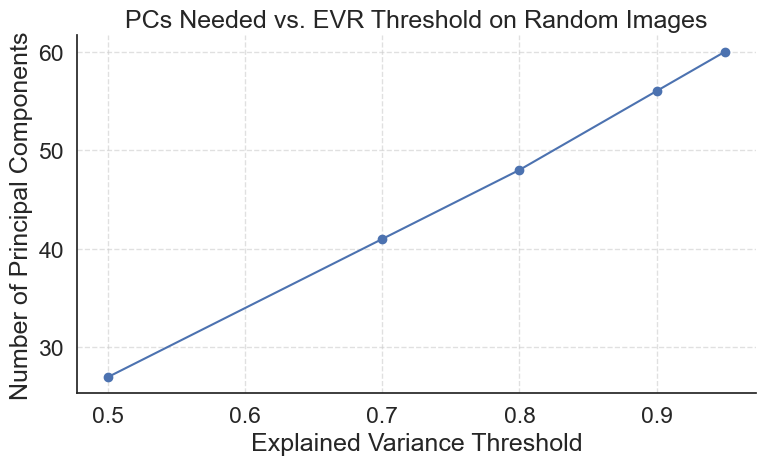

In [15]:
def random_image(image):
    random_image = np.random.rand(*image.shape) * 255
    return random_image

# load image data
dataset = load_digits()
images = dataset.data
random_images = [random_image(image) for image in images]
thresholds = [0.5, 0.7, 0.8, 0.9, 0.95]
pcs_needed = [get_N_pc(random_images, th) for th in thresholds]

plt.figure(figsize=(8, 5))
plt.plot(thresholds, pcs_needed, marker='o', linestyle='-')
plt.xlabel('Explained Variance Threshold')
plt.ylabel('Number of Principal Components')
plt.title('PCs Needed vs. EVR Threshold on Random Images')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

So first of all, the curve for random images lies higher in general than the one for digits. 
There is about +20 components bias for the random images.

In addition, the curve for digits is exponential shaped, whereas that for random images is linear shaped.
That means that for relatively lower variances, the digits need less principal components.

That makes sense as digits have all sorts of covariances and correlations in the pixels that the random images don't have.
And these are used as information source, meaning, less principal components explains more of the variance.

Or perhaps there's just too much variance in the random data to begin with, but I feel like that's saying the same in different words.

## Exercise 2: cortical dynamics

Work with the cortical data we used in the lesson. Write some code that lets you easily chose a specific behavioural event from the `trial_data` dictionary (the recorded events are `CSp` for positive conditioned stimulus, `CSn` for negative conditioned stimulus and `licks` for lick events), one of the principal components, an onset time and and offset time, and plots the timecourse of this component in the selected period around the chosen event type.

Use this code to explore the data: how do different components behave? Do you notice any patterns? How would you test for the statistical significance of the effects that you see (if any)?

In [32]:
import pickle
from typing import Literal
from scipy.stats import sem
from scipy.ndimage import gaussian_filter1d

with open('./data/behaviour.pickle', 'rb') as handle:
    trial_data = pickle.load(handle)

voltage_signal = np.load('./data/voltage_signal.npy')
cortex_mask = np.load('./data/cortex_mask.npy')

X = voltage_signal.transpose(2,0,1) # reshape in time x image format
T,h,w = X.shape # saves time, height and width for future use
X = X[:,cortex_mask] # select only cortex pixels, returns a flattened image

pca = PCA(n_components=50);
pca.fit(X)

evr = pca.explained_variance_ratio_
c_evr = np.cumsum(evr)

def plot_event_data(event_name: Literal['CSp', 'CSn', 'Lick'], comp: int, onset: int, offset: int):
    PCs = pca.components_[:10,:].T # select and transpose first 10 PCs weights
    Y = X @ PCs # compute the PC timecourse, by projecting the original data on each component

    framerate = 50. #in Hz
    start_time = onset #seconds, relative to lick onset
    end_time = offset #seconds, relative to lick offset

    frame_times = trial_data['frames'] #frame times

    peri_Y = [] #empty list for peri-lick timecourses

    #cycle over licking onsets
    for i in trial_data[event_name]:
        onset_frame = np.argmin(abs(frame_times-i)) #take frame closest to onset
        start_frame = int(onset_frame + framerate*start_time/1.000) # compute starting frame
        end_frame = int(onset_frame + framerate*end_time/1.000) # compute ending frame
        peri_Y.append(Y[start_frame:end_frame]) #saves the slice of Y

    peri_Y = np.asarray(peri_Y) 

    mean_Y = np.mean(peri_Y,axis=0) #average over licks
    error = sem(peri_Y,axis=0) #compute sem over licks

    plt.figure(figsize=(10,5))
    t = np.linspace(start_time,end_time,int((end_time-start_time)*framerate))
    y = mean_Y[:,comp-1]
    err = error[:,comp-1]

    y = gaussian_filter1d(y,2)
    err = gaussian_filter1d(err,2)

    plt.plot(t,y)
    plt.fill_between(t,y-err,y+err,alpha=0.2)

    plt.xlabel('Time (s)')
    plt.ylabel('PC activation (a.u.)')

    plt.axvline(x=0,linestyle='--',label=f'{event_name} onset')
    plt.legend()


C:\Users\EmielNagel\AppData\Local\Temp\ipykernel_10744\4017722500.py:7: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  trial_data = pickle.load(handle)


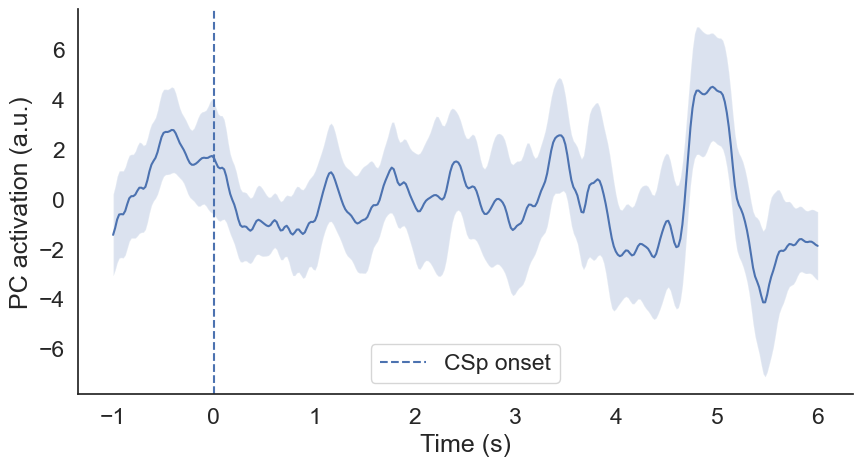

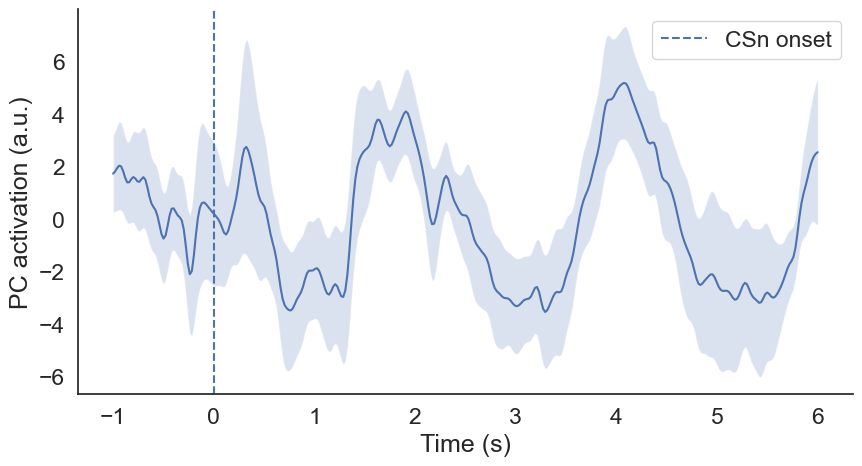

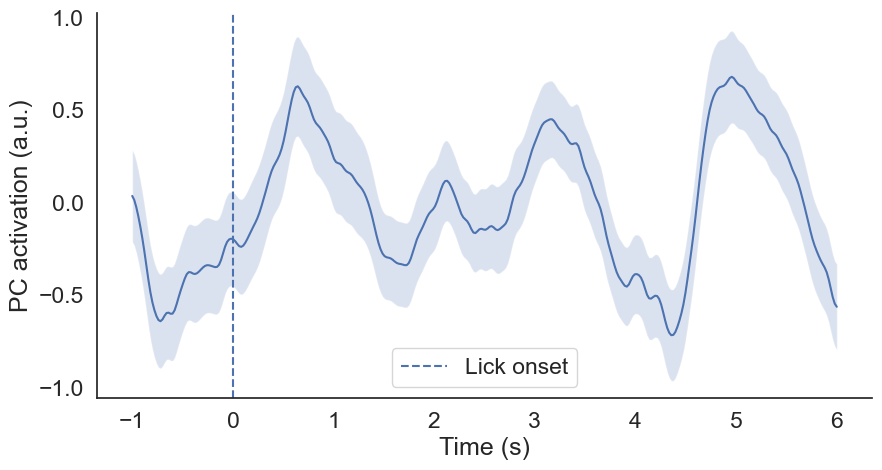

In [45]:
plot_event_data('CSp', 1, -1.0, 6.0)
plot_event_data('CSn', 1, -1.0, 6.0)
plot_event_data('Lick', 1, -1.0, 6.0)

The CSp and CSn seem to behave rather similarly.
I would say that CSp has a better balance between frequency of peaks and sustained oscillation, whereas the CSn has more plateau-like behavior at times, but I can't say with certainty.

The lick data is entirely different. There is much less noise and the values only range from -0.75 to 0.75 (as opposed to CSp and CSn which are both in the ballpark of -5 till 5). 

Furthermore, CSn and Lick seem very much linked with each other.
When CSn is high, Lick is low, and vice versa.
And CSp seems to do its own thing entirely.

To examine these effects we can compare two of the onsets with each other to ask “do these curves covary over time?”
If we want to, we can even use a sliding window approach to determine at which timepoints their relationships are the strongest.

If we see a sustained high value, that means that these two onsets are indeed very much related.

## Exercise 3: nonlinear dimensionality reduction

Using the MNIST digit dataset, explore the effect of hyperparameters on the result of nonlinear dimensionality reduction methods.

- Change the `perplexity` and `exageration` parameters in `TNSE` (one at a time). Graphically compare the results of different values.
- Change the neighbourhood size in `Isomap` (set by the parameter `n_neighbors`), and visualize how the results change.

Finally, try to apply one or more of these methods to the cortical data we used in the lessons. How do the data look in two dimensions? Do any cluster seem to appear? Are they robust with respect to hyperparameter choice?

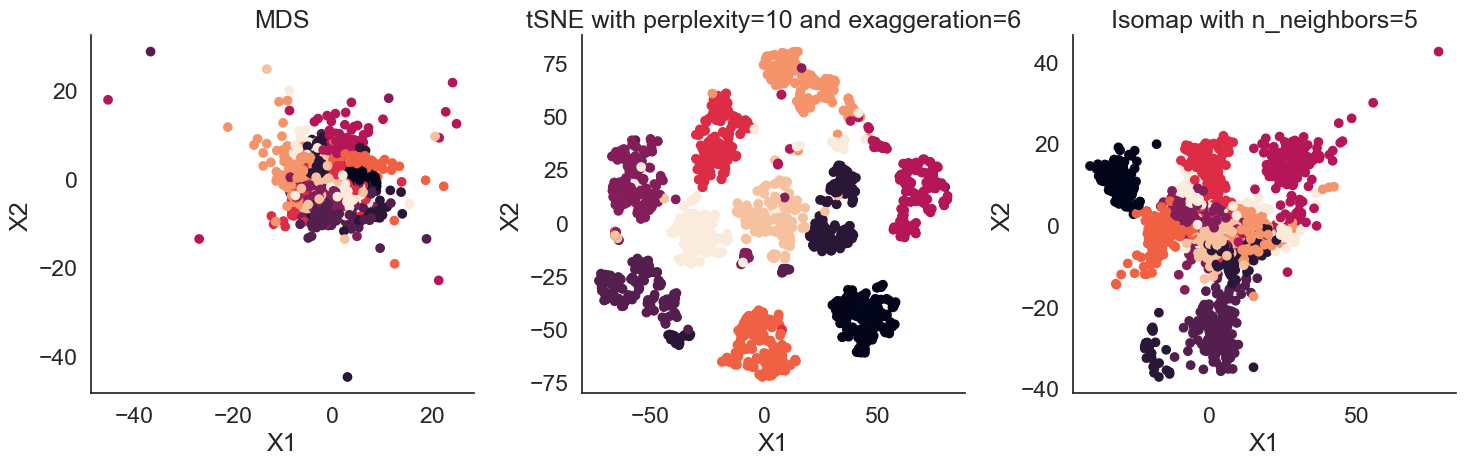

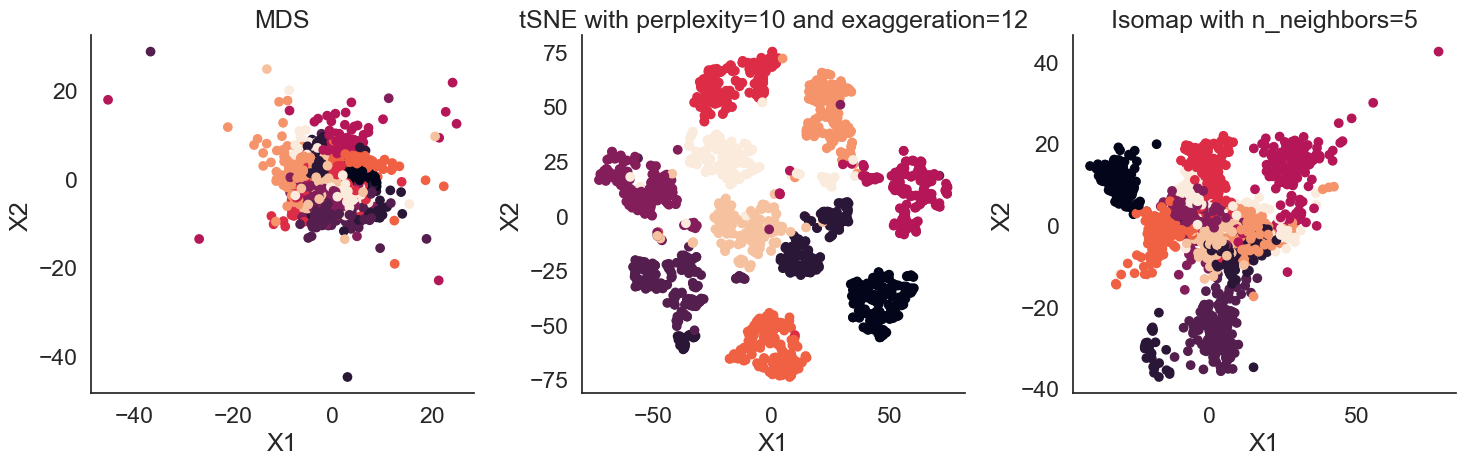

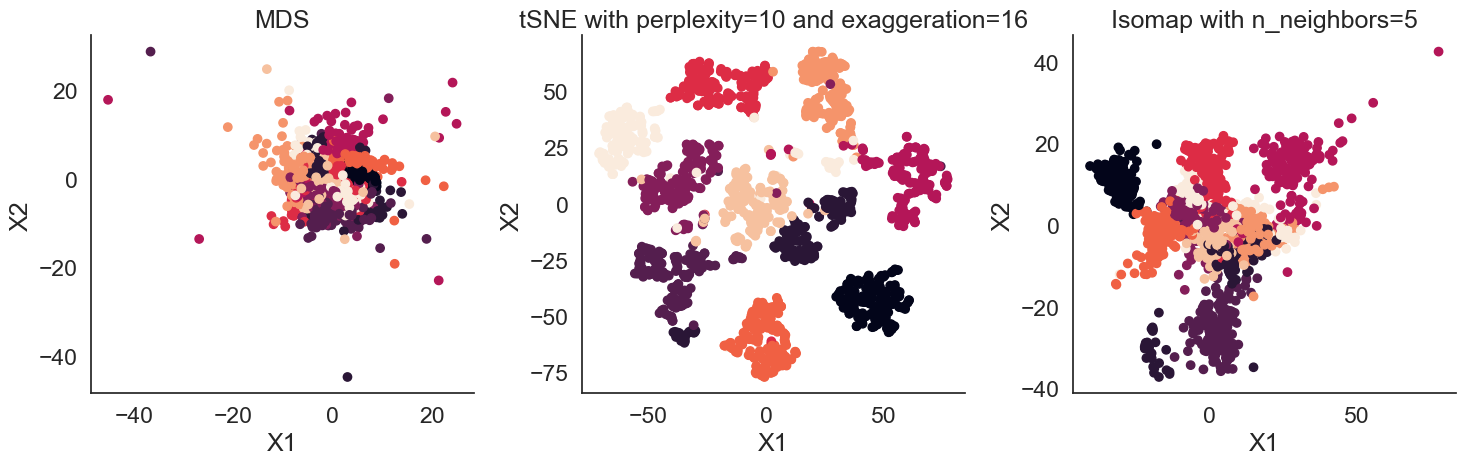

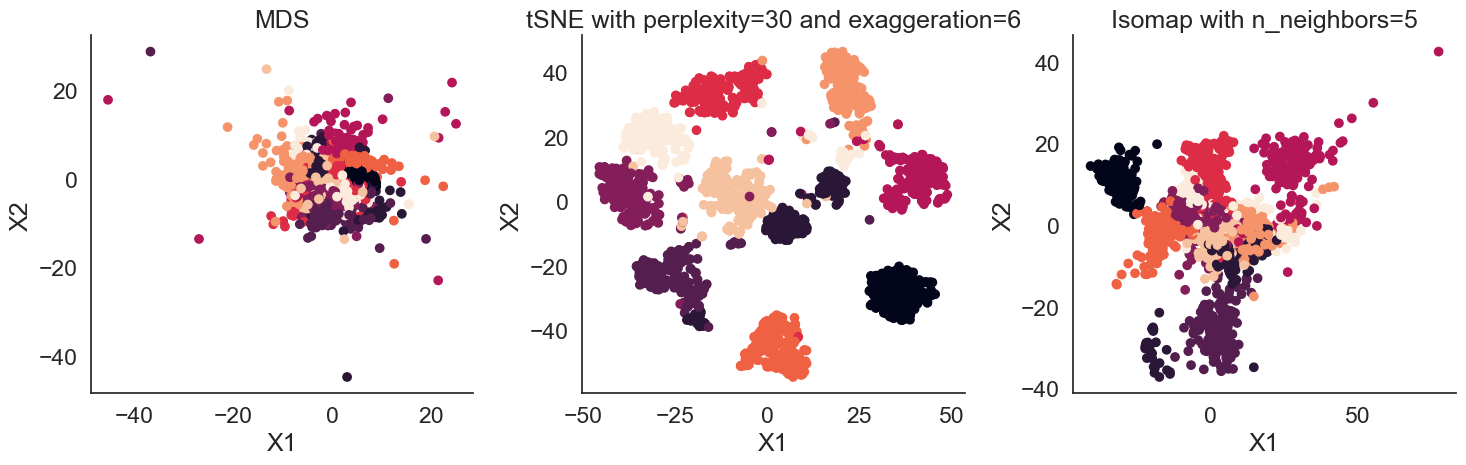

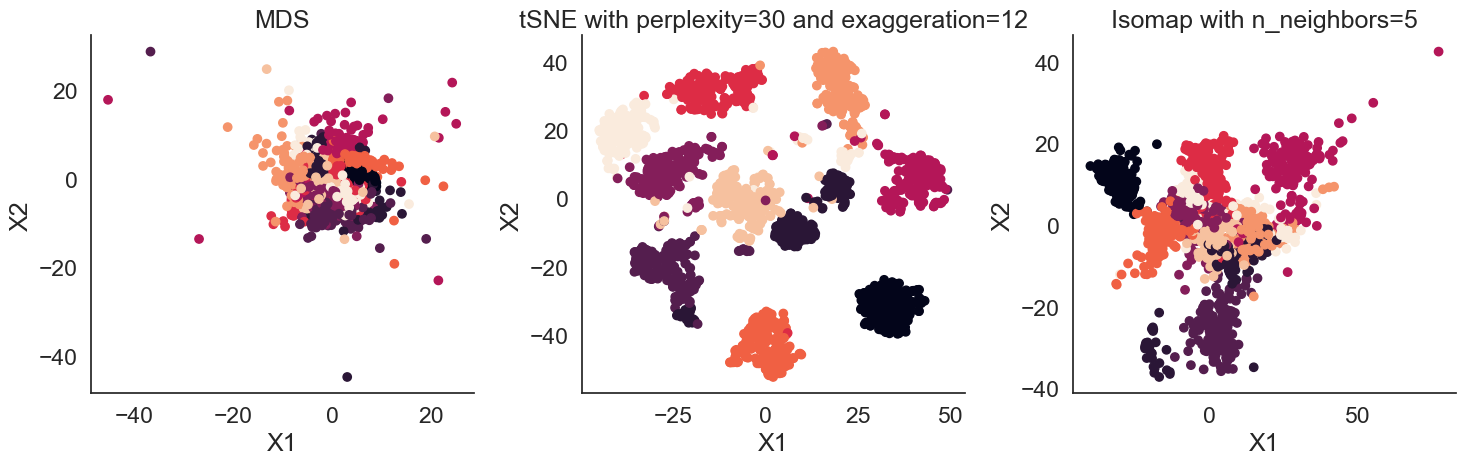

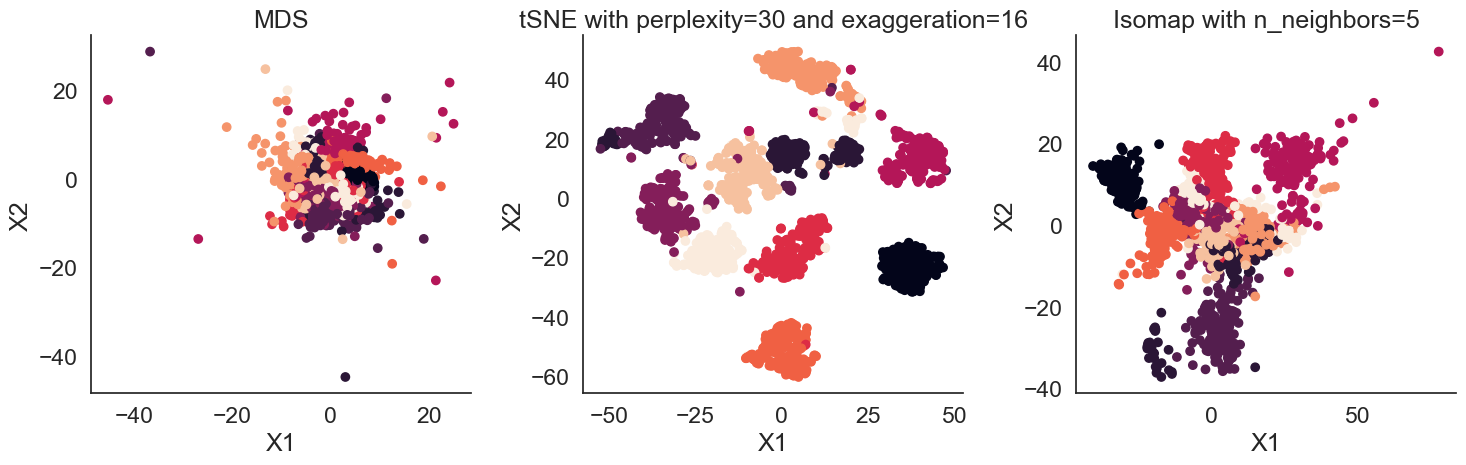

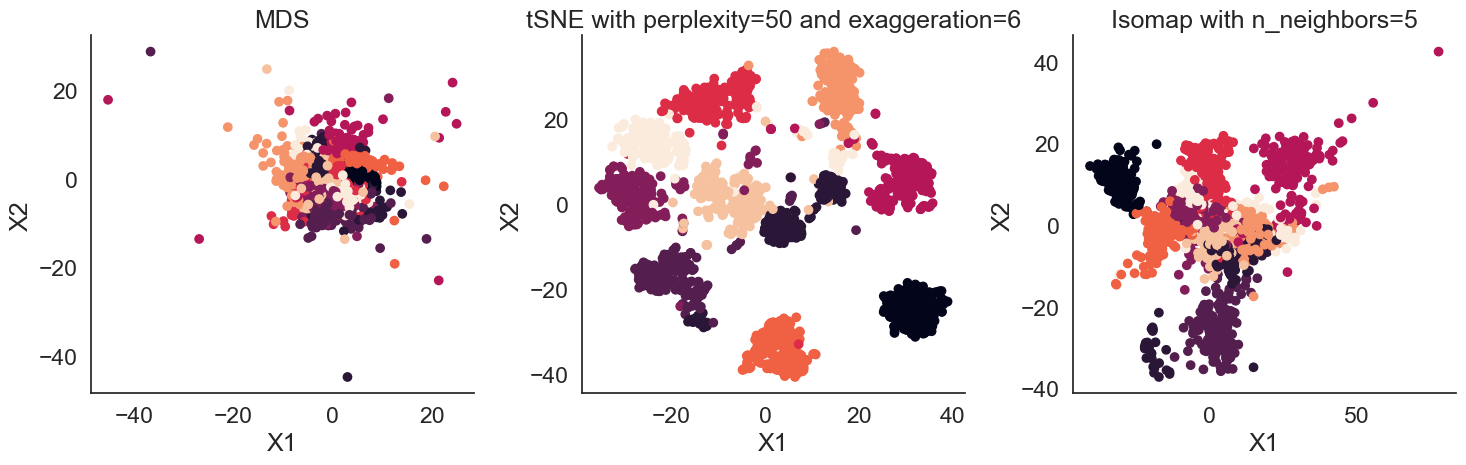

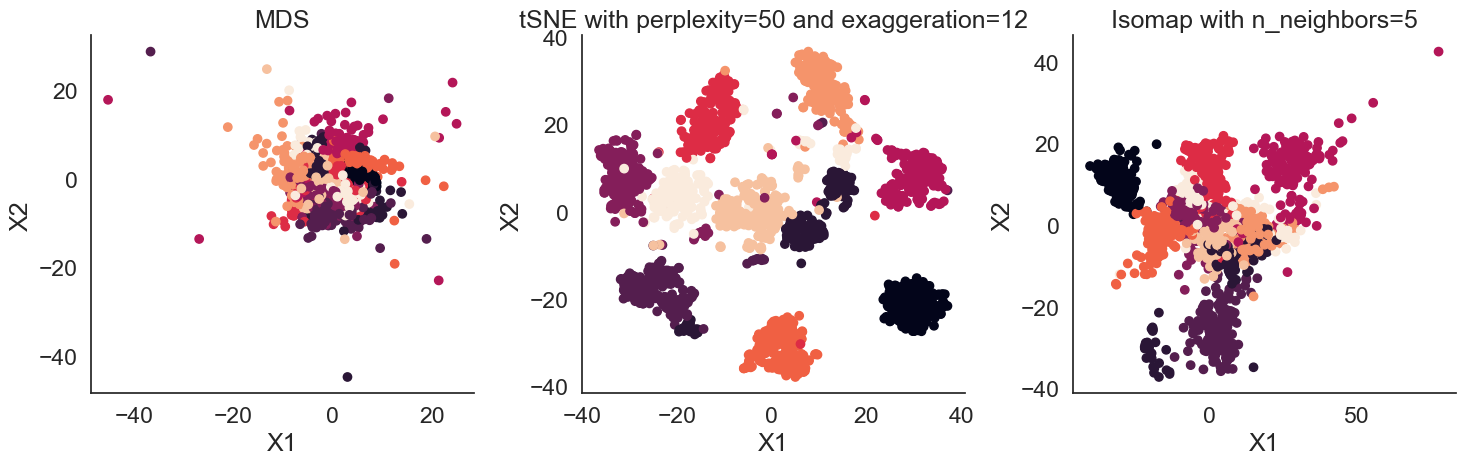

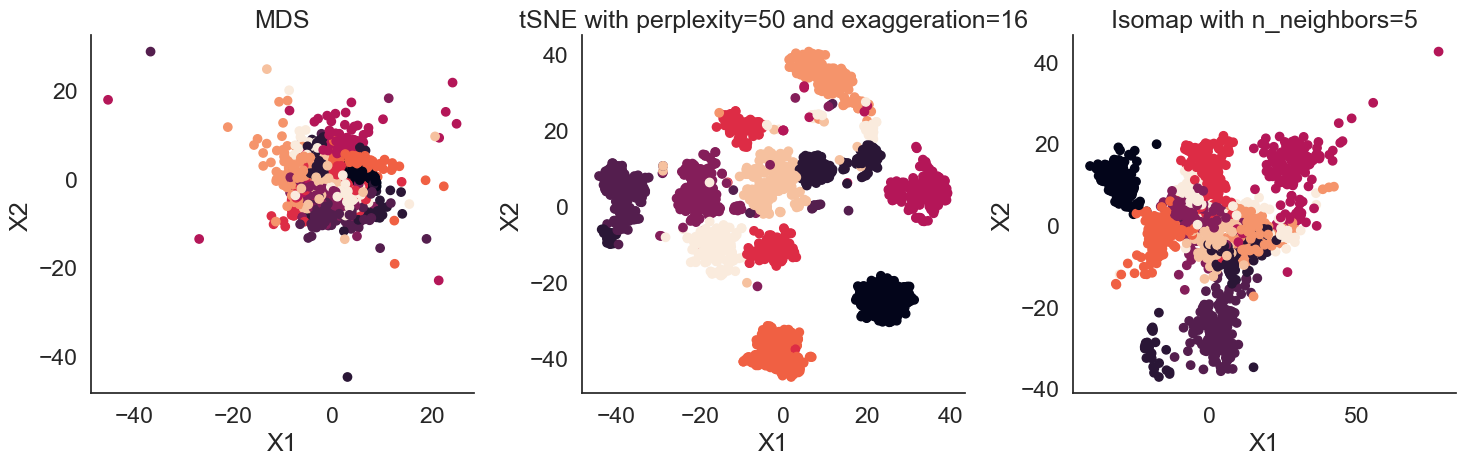

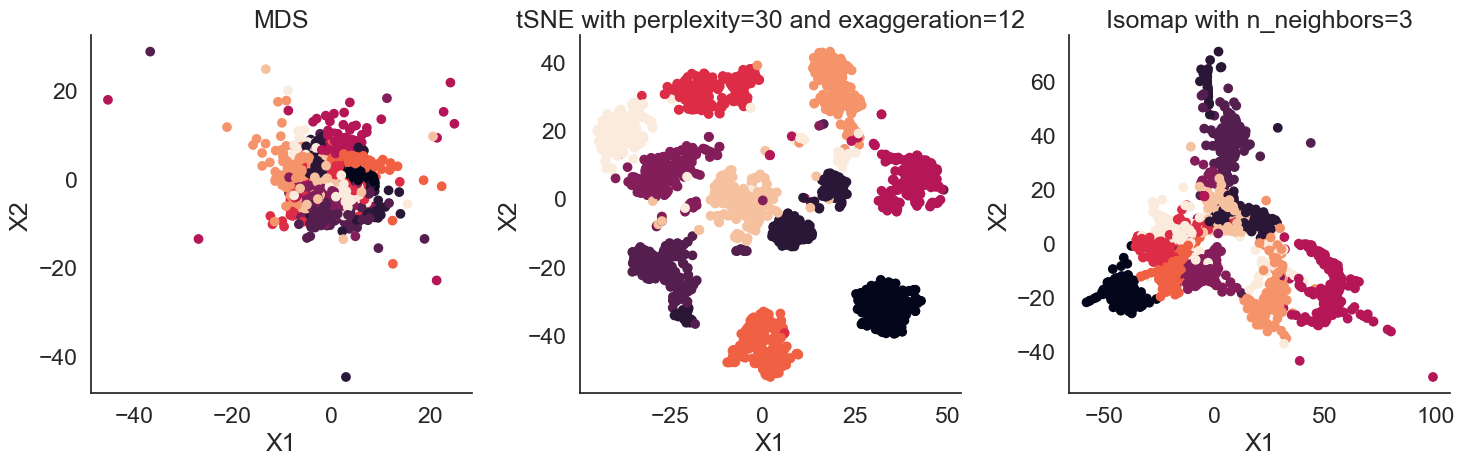

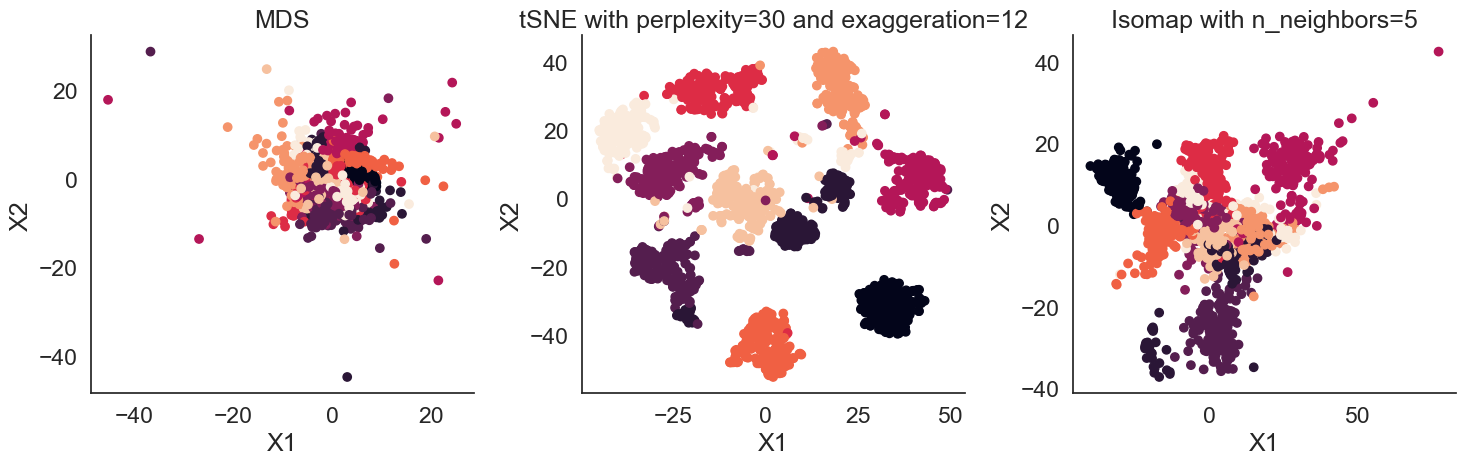

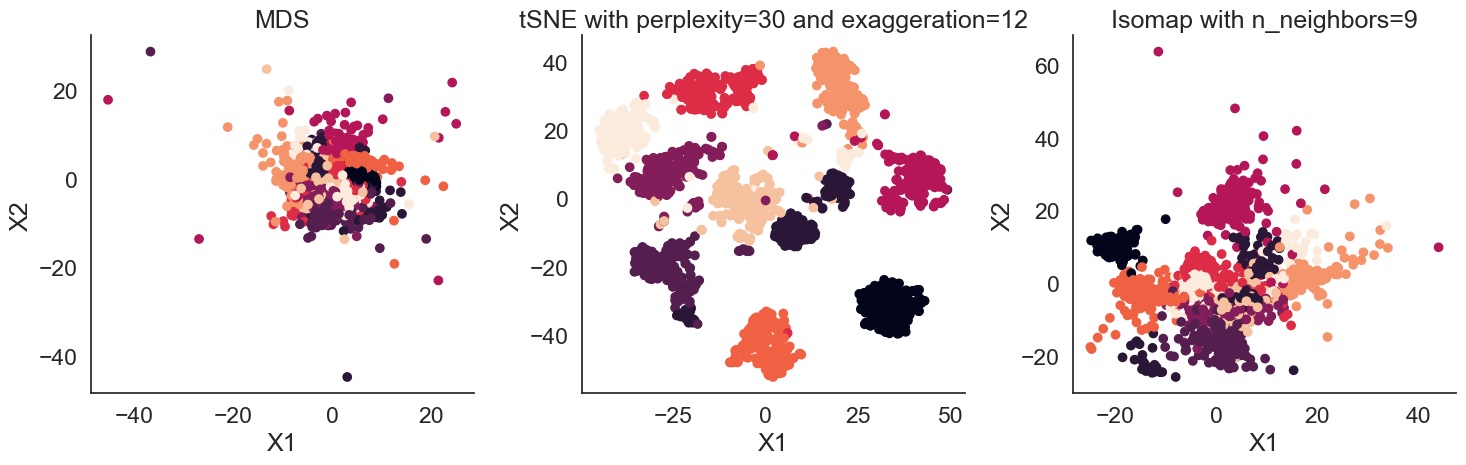

In [5]:
from sklearn.manifold import MDS
from sklearn.manifold import TSNE
from sklearn.manifold import Isomap

def plot(X_mds, X_tsne, X_iso, perplexity, exageration, n_neighbors):

    plt.figure(figsize=(15,5))
    plt.subplot(1,3,1)
    plt.scatter(X_mds[:,0],X_mds[:,1],c=dataset.target)
    plt.title('MDS')
    plt.xlabel('X1')
    plt.ylabel('X2')

    plt.subplot(1,3,2)
    plt.scatter(X_tsne[:,0],X_tsne[:,1],c=dataset.target)
    plt.title(f'tSNE with perplexity={perplexity} and exaggeration={exageration}')
    plt.xlabel('X1')
    plt.ylabel('X2')

    plt.subplot(1,3,3)
    plt.scatter(X_iso[:,0],X_iso[:,1],c=dataset.target)
    plt.title(f'Isomap with n_neighbors={n_neighbors}')
    plt.xlabel('X1')
    plt.ylabel('X2')

    plt.tight_layout()


# load and preprocess data
dataset = load_digits()
images = dataset.data
X = StandardScaler().fit_transform(images)

for perplexity in [10, 30, 50]:
    for exageration in [6, 12, 16]:
        # initialize embedding calculator
        mds = MDS(n_components=2,random_state=0,normalized_stress='auto')
        tsne = TSNE(n_components=2,random_state=0, perplexity=perplexity, early_exaggeration=exageration)
        isomap = Isomap(n_components=2, n_neighbors=5)

        #fit emebddings and transform data
        X_mds = mds.fit_transform(X)
        X_tsne = tsne.fit_transform(X)
        X_iso = isomap.fit_transform(X)

        plot(X_mds, X_tsne, X_iso, perplexity, exageration, 5)

for n_neighbors in [3, 5, 9]:
    # initialize embedding calculator
    mds = MDS(n_components=2,random_state=0,normalized_stress='auto')
    tsne = TSNE(n_components=2,random_state=0, perplexity=30, early_exaggeration=12)
    isomap = Isomap(n_components=2, n_neighbors=n_neighbors)

    #fit emebddings and transform data
    X_mds = mds.fit_transform(X)
    X_tsne = tsne.fit_transform(X)
    X_iso = isomap.fit_transform(X)

    plot(X_mds, X_tsne, X_iso, 30, 12, n_neighbors)


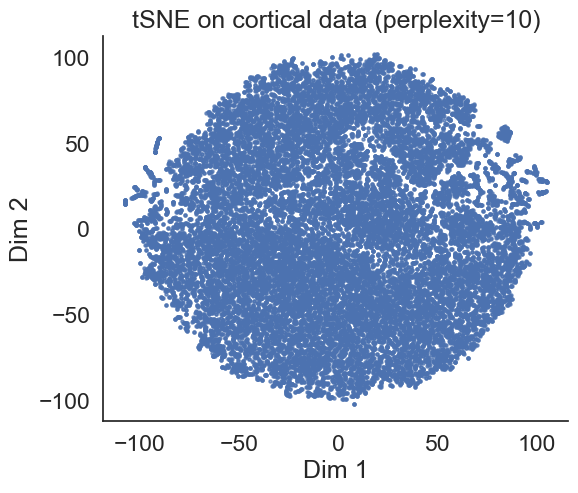

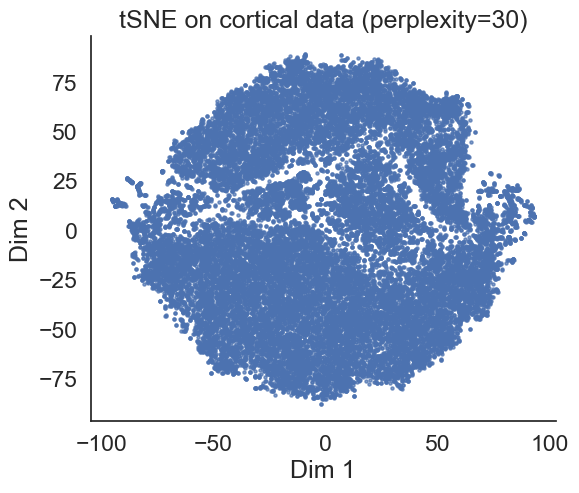

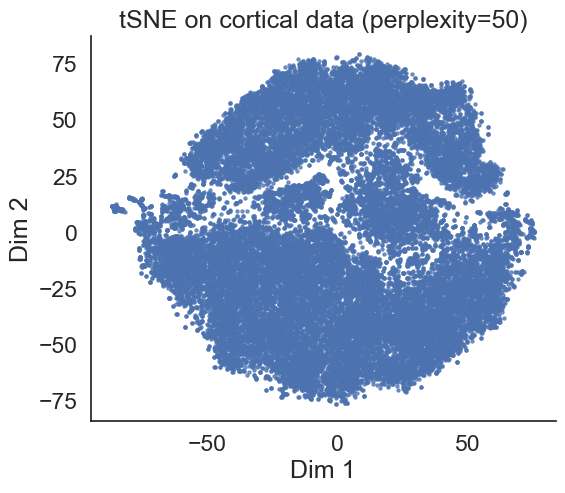

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\manifold\_isomap.py:383: UserWarning: The number of connected components of the neighbors graph is 5 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
C:\Users\Emiel\AppData\Roaming\Python\Python312\site-packages\scipy\sparse\_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
C:\Users\Emiel\AppData\Roaming\Python\Python312\site-packages\scipy\sparse\_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
C:\Users\Emiel\AppData\Roaming\Python\Python312\site-packages\scipy\sparse\_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  sel

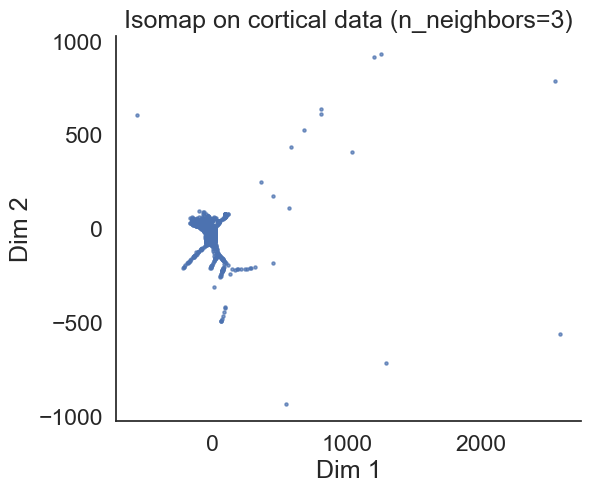

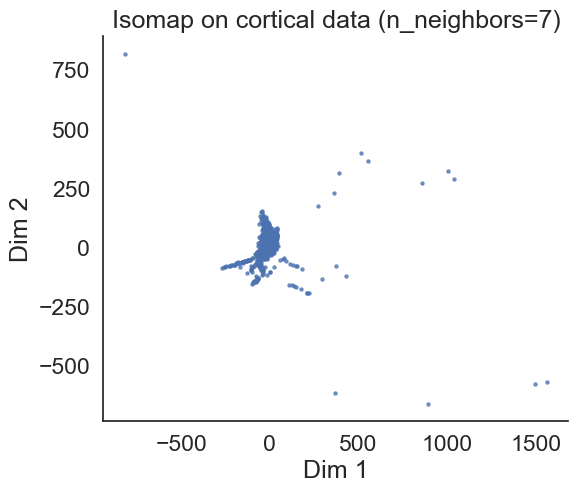

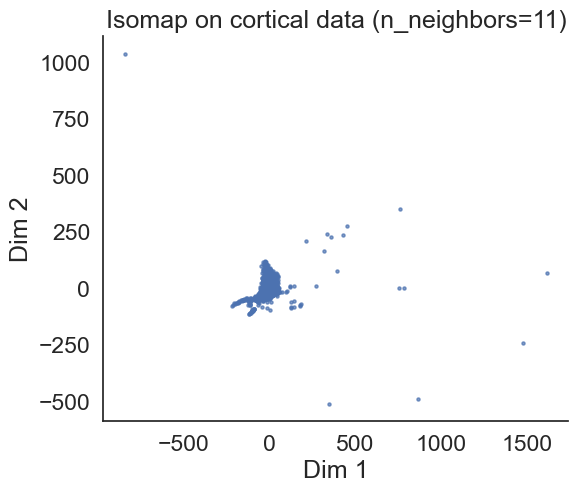

In [6]:
voltage_signal = np.load('./data/voltage_signal.npy')
cortex_mask = np.load('./data/cortex_mask.npy')

X = voltage_signal.transpose(2,0,1) # reshape in time x image format
T,h,w = X.shape
X = X[:,cortex_mask] # select only cortex pixels, returns a flattened image

X_pca = PCA(n_components=20).fit_transform(X)


from sklearn.manifold import TSNE, Isomap

# Try different t-SNE perplexities and Isomap n_neighbors
perplexities = [10, 30, 50]
n_neighbors_list = [3, 7, 11]

for perplexity in perplexities:
    tsne = TSNE(n_components=2, random_state=0, perplexity=perplexity)
    X_tsne = tsne.fit_transform(X_pca)
    plt.figure(figsize=(6,5))
    plt.scatter(X_tsne[:,0], X_tsne[:,1], s=5, alpha=0.7)
    plt.title(f'tSNE on cortical data (perplexity={perplexity})')
    plt.xlabel('Dim 1')
    plt.ylabel('Dim 2')
    plt.show()

for n_neighbors in n_neighbors_list:
    isomap = Isomap(n_components=2, n_neighbors=n_neighbors)
    X_iso = isomap.fit_transform(X_pca)
    plt.figure(figsize=(6,5))
    plt.scatter(X_iso[:,0], X_iso[:,1], s=5, alpha=0.7)
    plt.title(f'Isomap on cortical data (n_neighbors={n_neighbors})')
    plt.xlabel('Dim 1')
    plt.ylabel('Dim 2')
    plt.show()

For the tSNE:
It all appears to be one big cluster with rifts down the middle.
With perplexity = 50, or higher perplexity in general, the rift in the middle becomes more pronounced and some clusterrs do begin forming in this rift.
But it's all not very clearly separated.

It seems sort of robust, in that the general structure stays the same, but there is definitely some evolution.


For the Isomap:
There is one tiny cluster down in the middle that stays decently robust.
It changes around a bit, especially when going from 3 to 7 neighbours.
There aare also some tiny specs, and although they seem to spread similarly, their actual positions change a ton, especially relative to the space they take up.